# Análisis de Falsos Negativos Comunes en el Test Set

Este Notebook presenta la evaluación en el conjunto de prueba (Test Set) y el análisis visual interactivo de los **Falsos Negativos (FN)** que son compartidos por los tres modelos principales del proyecto:
* **Swin Small**
* **ViT Base**
* **CNN ResNet50**

### ¿Qué es un Falso Negativo (FN)?
Un Falso Negativo ocurre cuando un paciente que **realmente tiene una rotura de LCA** (Ground Truth = 1) es diagnosticado incorrectamente por los modelos como **Sano** (Predicción = 0).
Es el tipo de error más crítico en el ámbito médico, ya que puede retrasar un tratamiento quirúrgico o la terapia física adecuada.

## 1. Setup y Carga de Módulos

In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Insertar la ruta raíz para importar src
sys.path.insert(0, '/home/palodo2/acl_classifier')

# Configurar visualización de gráficos
%matplotlib inline
plt.rcParams['figure.figsize'] = (20, 8.5)
print("Entorno inicializado correctamente.")

Entorno inicializado correctamente.


## 2. Análisis del Solapamiento de Errores

Cargamos el archivo CSV detallado de fallos generado en el Test Set para verificar las probabilidades y predicciones obtenidas por cada modelo.

In [2]:
detailed_csv_path = Path('/home/palodo2/acl_classifier/scratch/detailed_failures.csv')
if detailed_csv_path.exists():
    df_failures = pd.read_csv(detailed_csv_path)
 # Filtrar únicamente los Falsos Negativos compartidos por los 3 modelos
 # (GroundTruth == 1 y fallan los 3, lo que significa que predijeron 0)
    df_fn = df_failures[
        (df_failures['GroundTruth'] == 1) &
        (df_failures['SwinPred'] == 0) &
        (df_failures['ViTPred'] == 0) &
        (df_failures['CNNPred'] == 0)
    ]
    print(f" Se encontraron {len(df_fn)} Falsos Negativos comunes:")
    display(df_fn)
else:
    print("Error: No se encontró el archivo detailed_failures.csv en scratch.")

 Se encontraron 3 Falsos Negativos comunes:


,Case,GroundTruth,SwinProb,SwinPred,SwinFail,ViTProb,ViTPred,ViTFail,CNNProb,CNNPred,CNNFail
2,80,1,0.2473,0,1,0.1101,0,1,0.3805,0,1
3,87,1,0.3115,0,1,0.2274,0,1,0.5338,0,1
14,521,1,0.2708,0,1,0.1721,0,1,0.4899,0,1


## 3. Función de Visualización Detallada (Sin Solapar Textos)

Definimos la función para graficar los 25 cortes analizados para un caso determinado (5 sagitales, 10 coronales y 10 axiales).
Los nombres de los planos anatómicos se colocan a la izquierda de cada fila y los números de los cortes arriba, dejando las imágenes de resonancia magnética completamente libres de texto superpuesto.

In [3]:
def plot_all_analyzed_slices(case_id, data_dir=Path('/home/palodo2/acl_classifier/data')):
    planes = ['sagittal', 'coronal', 'axial']

 # Cargar caches de índices precalculados
    caches = {}
    for plane in planes:
        cache_path = data_dir / 'slice_indices_final' / f'test_{plane}_indices.json'
        with open(cache_path, 'r') as f:
            caches[plane] = json.load(f)

    fig, axes = plt.subplots(3, 10, figsize=(20, 8.5))

    plane_display_names = {
        'sagittal': 'SAGITAL\n(5 cortes)',
        'coronal': 'CORONAL\n(10 cortes)',
        'axial': 'AXIAL\n(10 cortes)'
    }

    for row_idx, plane in enumerate(planes):
        vol_path = data_dir / 'test' / plane / f"{int(case_id):04d}.npy"
        if not vol_path.exists():
            print(f"No se encontró el volumen: {vol_path}")
            continue

        vol = np.load(vol_path)
        selected_indices = caches[plane][str(int(case_id))]
        num_slices = len(selected_indices)

        for col_idx in range(10):
            ax = axes[row_idx, col_idx]

 # Ocultar bordes de la subfigura y marcas de los ejes para limpieza visual
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['bottom'].set_visible(False)
            ax.spines['left'].set_visible(False)
            ax.set_xticks([])
            ax.set_yticks([])

            if col_idx < num_slices:
                slice_idx = selected_indices[col_idx]
                slice_img = vol[slice_idx]
                ax.imshow(slice_img, cmap='bone')
                ax.set_title(f"Corte {slice_idx}", fontsize=9, pad=4)
            else:
 # Desactivar celdas vacías (plano sagital solo tiene 5 cortes)
                ax.axis('off')

 # Colocar la etiqueta del plano a la izquierda de la primera columna
            if col_idx == 0:
                ax.set_ylabel(plane_display_names[plane], fontsize=12, fontweight='bold',
                              labelpad=25, rotation=0, va='center', ha='right')

    fig.suptitle(f"Caso {case_id} (Falso Negativo Común - Real: Roto, IA: Sano)",
                 fontsize=16, fontweight='bold', y=0.98)

    plt.subplots_adjust(top=0.90, bottom=0.05, left=0.12, right=0.98, hspace=0.35, wspace=0.15)
    plt.show()

## 4. Visualización de los Casos de Falso Negativo

### Caso 0080

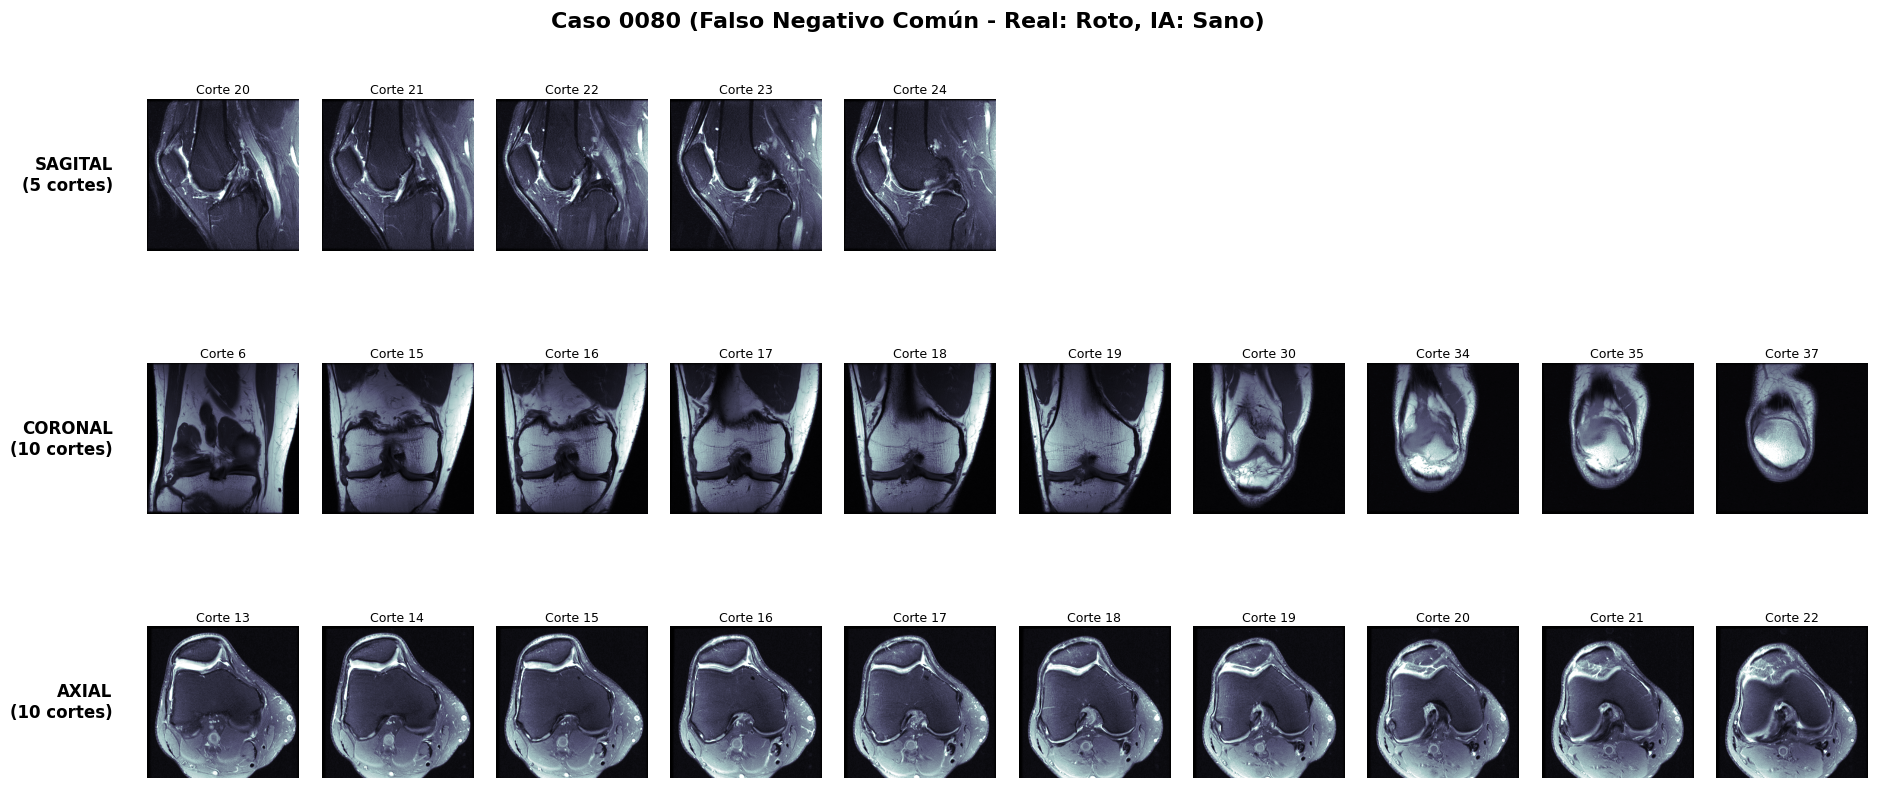

In [4]:
plot_all_analyzed_slices("0080")

### Caso 0087

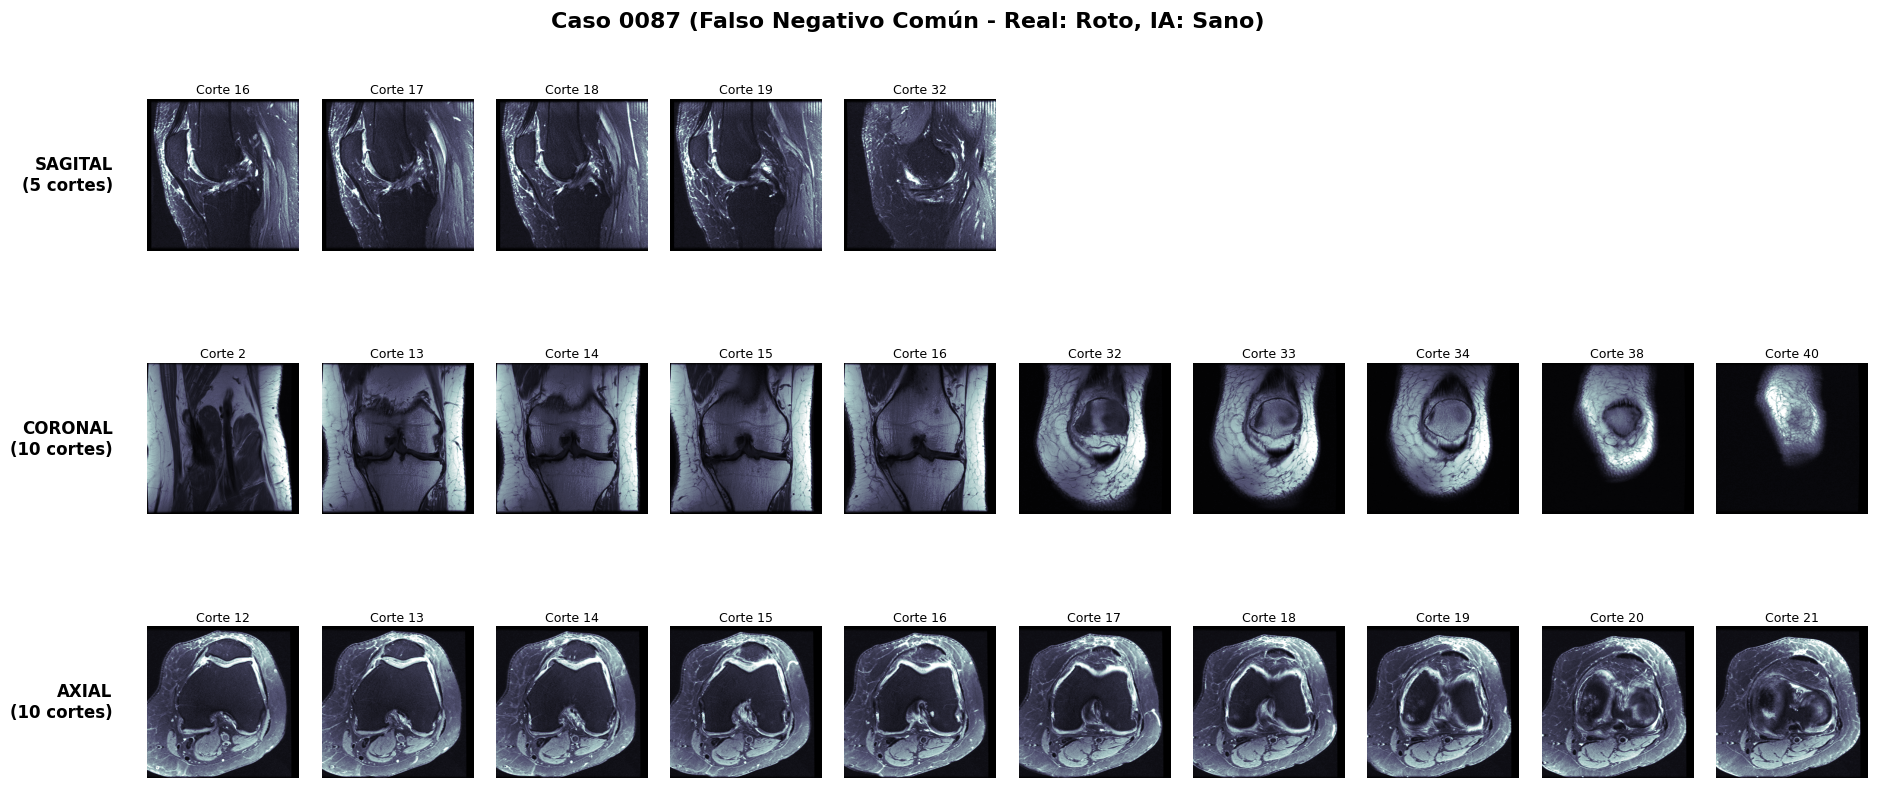

In [5]:
plot_all_analyzed_slices("0087")

### Caso 0521

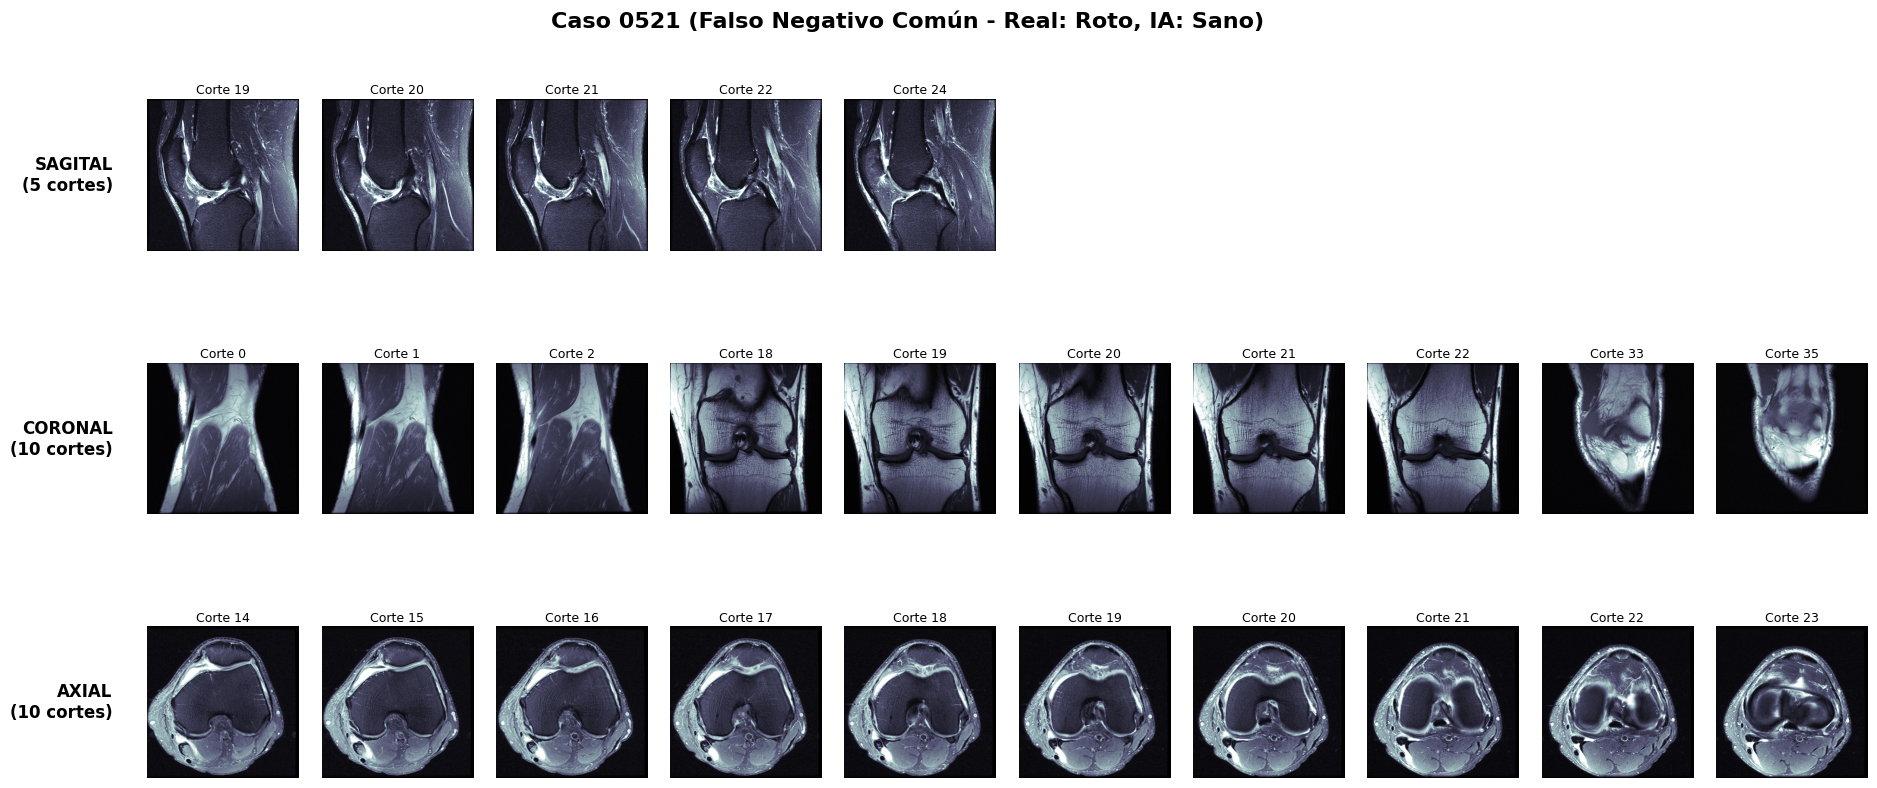

In [6]:
plot_all_analyzed_slices("0521")